In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Анализ данных Папа Джонс")

Анализ данных Папа Джонс


In [5]:
df = pd.read_csv('/content/papa_johns_top100_posts.csv')

print("Первые 5 строк данных:")
display(df.head())

print(f"Размер данных: {df.shape}")
print(f"Период данных: с {df['date'].min()} по {df['date'].max()}")

Первые 5 строк данных:


,post_id,likes,text_preview,date,link
0,118041,1283,NaN,2025-05-14 10:22:09,https://vk.com/wall-10095732_118041
1,7858,1258,[https://m.vk.com/papajohnsru|Папа Джонс] и [h...,2025-07-24 15:00:18,https://vk.com/wall-10095732_7858
2,117823,1226,У нас просто нет слов! Но ты точно найдешь по...,2025-04-06 18:20:49,https://vk.com/wall-10095732_117823
3,118977,961,9 августа поддержали OviCup — ежегодный турнир...,2025-08-12 15:17:31,https://vk.com/wall-10095732_118977
4,115199,756,🍕👕 Розыгрыш Папа Джонс и button blue [club5...,2024-08-19 15:05:29,https://vk.com/wall-10095732_115199


Размер данных: (100, 5)
Период данных: с 2021-01-05 08:33:55 по 2025-11-06 12:49:26


In [6]:
print("Проверка пропусков:")
print(df.isnull().sum())

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.day_name()
df['text_length'] = df['text_preview'].fillna('').str.len()
df['has_text'] = df['text_preview'].notna()

print("Предобработка завершена")

Проверка пропусков:
post_id          0
likes            0
text_preview    22
date             0
link             0
dtype: int64
Предобработка завершена


Анализ лайков
Статистика по лайкам:
Среднее: 136.9
Медиана: 51.5
Максимум: 1283.0
Минимум: 32.0


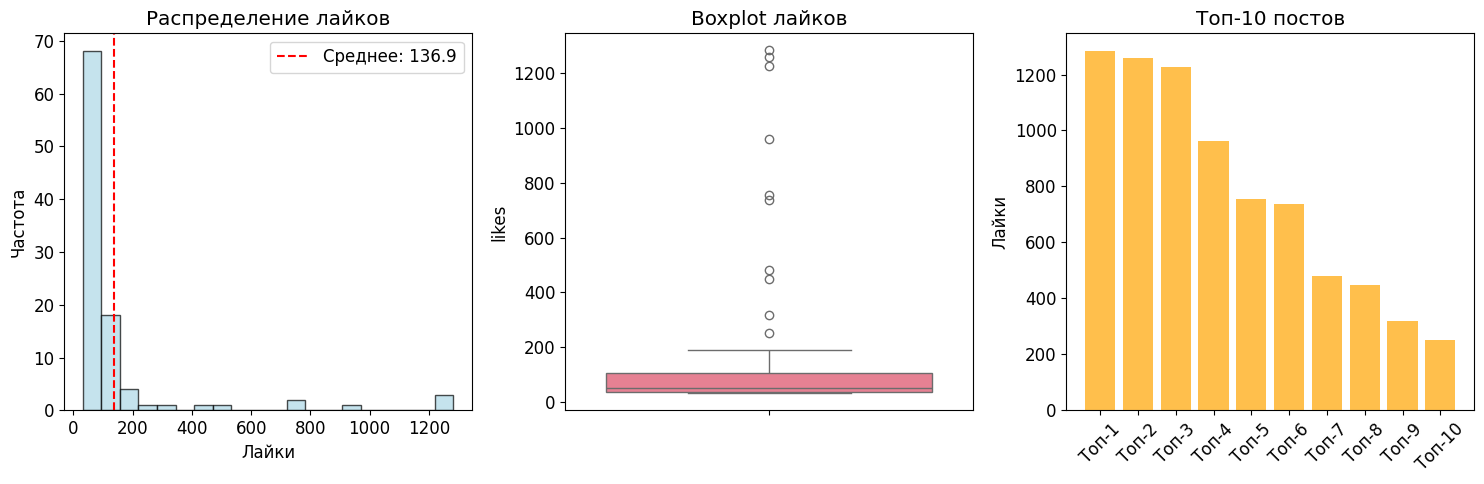

In [7]:
print("Анализ лайков")

likes_stats = df['likes'].describe()
print("Статистика по лайкам:")
print(f"Среднее: {likes_stats['mean']:.1f}")
print(f"Медиана: {likes_stats['50%']:.1f}")
print(f"Максимум: {likes_stats['max']:.1f}")
print(f"Минимум: {likes_stats['min']:.1f}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df['likes'], bins=20, color='lightblue', edgecolor='black', alpha=0.7)
plt.axvline(df['likes'].mean(), color='red', linestyle='--', label=f'Среднее: {df["likes"].mean():.1f}')
plt.xlabel('Лайки')
plt.ylabel('Частота')
plt.title('Распределение лайков')
plt.legend()

plt.subplot(1, 3, 2)
sns.boxplot(y=df['likes'])
plt.title('Boxplot лайков')

plt.subplot(1, 3, 3)
top_10 = df.nlargest(10, 'likes')
plt.bar(range(10), top_10['likes'], color='orange', alpha=0.7)
plt.xticks(range(10), [f'Топ-{i+1}' for i in range(10)], rotation=45)
plt.title('Топ-10 постов')
plt.ylabel('Лайки')

plt.tight_layout()
plt.show()

In [8]:
print("Топ-5 самых популярных постов")

top_5 = df.nlargest(5, 'likes')[['likes', 'text_preview', 'date']]

for i, row in top_5.iterrows():
    print(f"{i+1}. {row['likes']} лайков ({row['date'].strftime('%d.%m.%Y')})")
    text = str(row['text_preview'])[:80] + '...' if len(str(row['text_preview'])) > 80 else str(row['text_preview'])
    print(f"   {text}")

Топ-5 самых популярных постов
1. 1283 лайков (14.05.2025)
   nan
2. 1258 лайков (24.07.2025)
   [https://m.vk.com/papajohnsru|Папа Джонс] и [https://vk.com/sin_official|СИН] об...
3. 1226 лайков (06.04.2025)
   У нас просто нет слов!  Но ты точно найдешь подходящие, чтобы поздравить Алексан...
4. 961 лайков (12.08.2025)
   9 августа поддержали OviCup — ежегодный турнир Александра Овечкина. И это было м...
5. 756 лайков (19.08.2024)
   🍕👕 Розыгрыш Папа Джонс и button blue    [club56770668|Button Blue] — это что-то ...


Анализ по времени


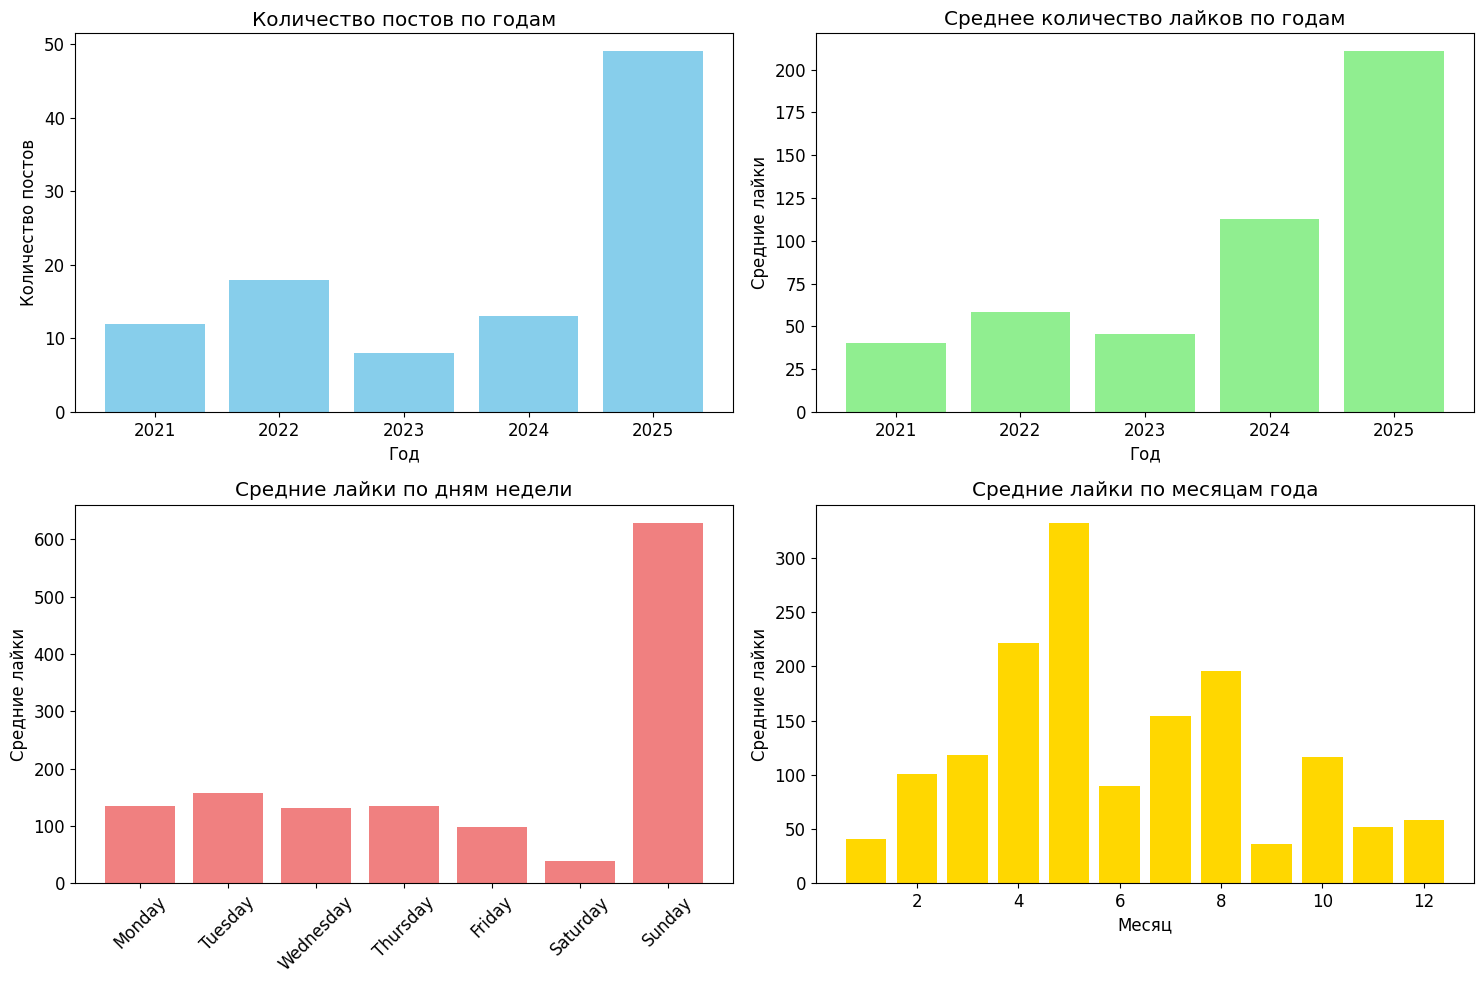

In [9]:
print("Анализ по времени")

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
yearly = df.groupby('year').agg({'likes': ['count', 'mean']})
yearly.columns = ['count', 'mean_likes']
plt.bar(yearly.index, yearly['count'], color='skyblue')
plt.title('Количество постов по годам')
plt.xlabel('Год')
plt.ylabel('Количество постов')

plt.subplot(2, 2, 2)
plt.bar(yearly.index, yearly['mean_likes'], color='lightgreen')
plt.title('Среднее количество лайков по годам')
plt.xlabel('Год')
plt.ylabel('Средние лайки')

plt.subplot(2, 2, 3)
weekday_stats = df.groupby('day_of_week')['likes'].mean()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_stats = weekday_stats.reindex(weekday_order)
plt.bar(weekday_stats.index, weekday_stats.values, color='lightcoral')
plt.title('Средние лайки по дням недели')
plt.xticks(rotation=45)
plt.ylabel('Средние лайки')

plt.subplot(2, 2, 4)
monthly_stats = df.groupby('month')['likes'].mean()
plt.bar(monthly_stats.index, monthly_stats.values, color='gold')
plt.title('Средние лайки по месяцам года')
plt.xlabel('Месяц')
plt.ylabel('Средние лайки')

plt.tight_layout()
plt.show()

Анализ содержания постов
Распределение по категориям:
   Другое: 38 постов (38.0%)
   Без текста: 22 постов (22.0%)
   Конкурс: 19 постов (19.0%)
   Продукты: 10 постов (10.0%)
   Праздник: 7 постов (7.0%)
   Партнерство: 2 постов (2.0%)
   Спорт: 2 постов (2.0%)


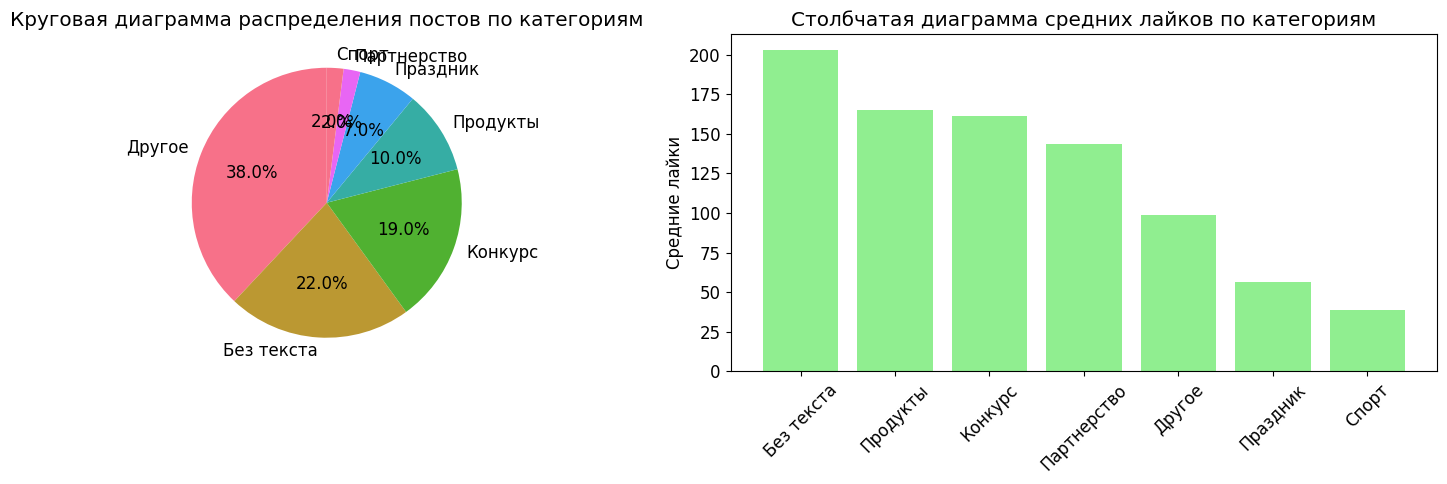

In [10]:
print("Анализ содержания постов")

def categorize_text(text):
    if pd.isna(text):
        return 'Без текста'

    text = str(text).lower()

    if 'розыгрыш' in text or 'конкурс' in text or 'выиграй' in text:
        return 'Конкурс'
    elif 'овочкин' in text or 'хоккей' in text:
        return 'Спорт'
    elif 'пицца' in text or 'меню' in text:
        return 'Продукты'
    elif 'партнер' in text or 'совместно' in text:
        return 'Партнерство'
    elif 'праздник' in text or 'день' in text:
        return 'Праздник'
    else:
        return 'Другое'

df['category'] = df['text_preview'].apply(categorize_text)

category_stats = df['category'].value_counts()
print("Распределение по категориям:")
for cat, count in category_stats.items():
    percent = (count / len(df)) * 100
    print(f"   {cat}: {count} постов ({percent:.1f}%)")

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.pie(category_stats.values, labels=category_stats.index, autopct='%1.1f%%', startangle=90)
plt.title('Круговая диаграмма распределения постов по категориям')

plt.subplot(1, 2, 2)
category_likes = df.groupby('category')['likes'].mean().sort_values(ascending=False)
plt.bar(category_likes.index, category_likes.values, color='lightgreen')
plt.xticks(rotation=45)
plt.title('Столбчатая диаграмма средних лайков по категориям')
plt.ylabel('Средние лайки')

plt.tight_layout()
plt.show()

Анализ связи длины текста и лайков


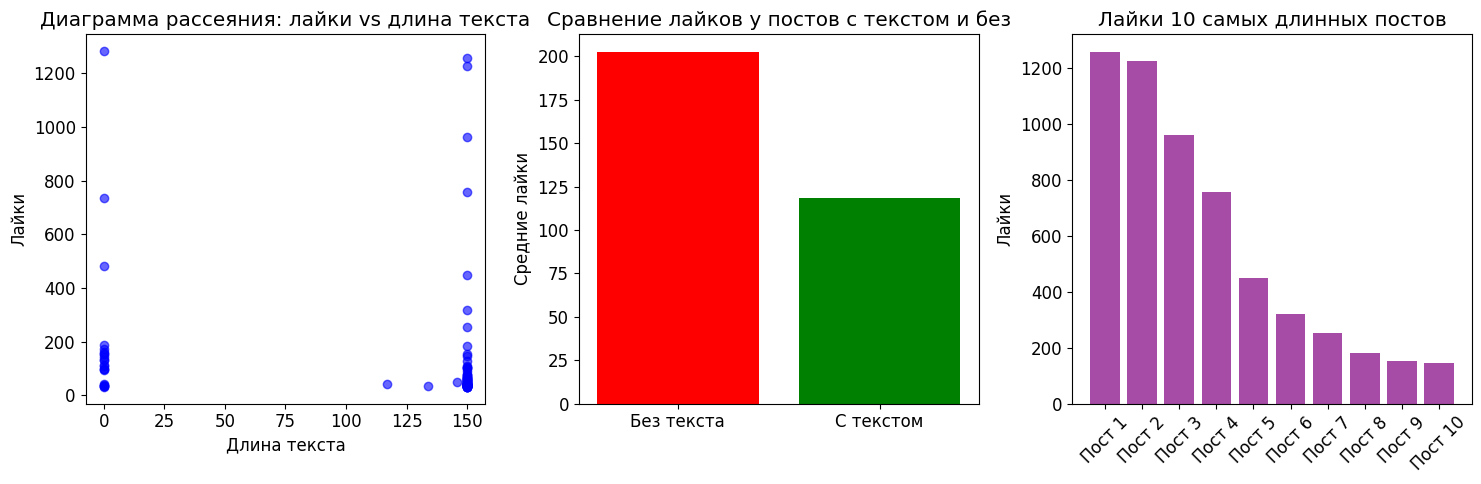

Корреляция длины текста и лайков: -0.139


In [11]:
print("Анализ связи длины текста и лайков")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(df['text_length'], df['likes'], alpha=0.6, color='blue')
plt.xlabel('Длина текста')
plt.ylabel('Лайки')
plt.title('Диаграмма рассеяния: лайки vs длина текста')

plt.subplot(1, 3, 2)
has_text_likes = df.groupby('has_text')['likes'].mean()
plt.bar(['Без текста', 'С текстом'], has_text_likes.values, color=['red', 'green'])
plt.title('Сравнение лайков у постов с текстом и без')
plt.ylabel('Средние лайки')

plt.subplot(1, 3, 3)
longest_posts = df.nlargest(10, 'text_length')
plt.bar(range(10), longest_posts['likes'], color='purple', alpha=0.7)
plt.xticks(range(10), [f'Пост {i+1}' for i in range(10)], rotation=45)
plt.title('Лайки 10 самых длинных постов')
plt.ylabel('Лайки')

plt.tight_layout()
plt.show()

correlation = df['text_length'].corr(df['likes'])
print(f"Корреляция длины текста и лайков: {correlation:.3f}")

In [12]:
print("Поиск паттернов")

best_year = df.groupby('year')['likes'].mean().idxmax()
best_year_likes = df.groupby('year')['likes'].mean().max()
print(f"Самый успешный год: {best_year} ({best_year_likes:.1f} лайков)")

best_day = df.groupby('day_of_week')['likes'].mean().idxmax()
best_day_likes = df.groupby('day_of_week')['likes'].mean().max()
print(f"Самый успешный день: {best_day} ({best_day_likes:.1f} лайков)")

best_category = df.groupby('category')['likes'].mean().idxmax()
best_category_likes = df.groupby('category')['likes'].mean().max()
print(f"Самая успешная категория: {best_category} ({best_category_likes:.1f} лайков)")

Q1 = df['likes'].quantile(0.25)
Q3 = df['likes'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['likes'] < Q1 - 1.5 * IQR) | (df['likes'] > Q3 + 1.5 * IQR)]
print(f"Выбросов: {len(outliers)} постов")

Поиск паттернов
Самый успешный год: 2025 (210.7 лайков)
Самый успешный день: Sunday (629.0 лайков)
Самая успешная категория: Без текста (202.8 лайков)
Выбросов: 10 постов


In [14]:
print("ВЫВОДЫ")

print("Основные наблюдения:")
print(f"1. Среднее количество лайков: {df['likes'].mean():.1f}")
print(f"2. Медианное количество лайков: {df['likes'].median():.1f}")
print(f"3. Разброс данных: от {df['likes'].min()} до {df['likes'].max()} лайков")
print(f"4. Самая частая категория: {category_stats.idxmax()}")
print(f"5. Корреляция длины текста и лайков: {correlation:.3f}")

print("Интересные факты:")
print(f"• Самый популярный пост: {df['likes'].max()} лайков")
print(f"• Постов без текста: {len(df[df['text_preview'].isna()])}")
print(f"• Лучший день для публикации: {best_day}")
print(f"• Самая вовлекающая тема: {best_category}")

print("Ограничения анализа:")
print("• Мало данных для глубоких выводов")
print("• Категории созданы вручную")
print("• Нет данных по комментариям и репостам")
print("• Анализ только топ-100 постов")

ВЫВОДЫ
Основные наблюдения:
1. Среднее количество лайков: 136.9
2. Медианное количество лайков: 51.5
3. Разброс данных: от 32 до 1283 лайков
4. Самая частая категория: Другое
5. Корреляция длины текста и лайков: -0.139
Интересные факты:
• Самый популярный пост: 1283 лайков
• Постов без текста: 22
• Лучший день для публикации: Sunday
• Самая вовлекающая тема: Без текста
Ограничения анализа:
• Мало данных для глубоких выводов
• Категории созданы вручную
• Нет данных по комментариям и репостам
• Анализ только топ-100 постов


In [15]:
print("Сохранение результатов...")

report = f"""
ОТЧЕТ ПО АНАЛИЗУ ДАННЫХ
Проект: Анализ постов Папа Джонс ВКонтакте
Дата: {datetime.now().strftime('%d.%m.%Y %H:%M')}

ОСНОВНЫЕ МЕТРИКИ:
Всего постов: {len(df)}
Среднее лайков: {df['likes'].mean():.1f}
Медиана лайков: {df['likes'].median():.1f}
Самый популярный пост: {df['likes'].max()} лайков

РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ:
{category_stats.to_string()}

ВЫВОДЫ:
1. Наиболее популярные посты: {best_category}
2. Лучшее время для публикации: {best_day}
3. Длина текста слабо влияет на лайки
"""

with open('analysis_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("Отчет сохранен как 'analysis_report.txt'")
print("Анализ завершен")

Сохранение результатов...
Отчет сохранен как 'analysis_report.txt'
Анализ завершен
